# 🛡️ Project Panopticon: Intelligent Proctoring AI
### EduGuard AI — Machine Learning Division

**Intern Name:** Navadeep Nomula  
**Project:** CAPSTONE — BOSS LEVEL  
**Date:** 19 September 2026

---

## Executive Summary

This notebook builds a time-series classification pipeline for intelligent online exam proctoring. The objective is to identify suspicious behavior while reducing false accusations against innocent students.

The pipeline follows the four required safeguards:

1. **Asynchronous temporal alignment** using `pandas.merge_asof`.
2. **Missing-data recovery** using forward-fill and interpolation instead of dropping the exam timeline.
3. **10-second rolling features** to reduce sensitivity to short-lived movements or sounds.
4. **Class-balanced Random Forest + probability thresholding**, using a strict **0.90 decision threshold** before flagging cheating.

> **Important:** A prediction is treated as a flag only when the model assigns at least 90% probability to the cheating class.

In [1]:
# ==========================================
# 0. IMPORT LIBRARIES
# ==========================================
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    average_precision_score,
    precision_recall_curve
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

RANDOM_STATE = 42
print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


## Phase 1 — Data Ingestion & Temporal Alignment

The supplied CSV datasets are embedded in this notebook, so the project runs directly in Google Colab without a separate CSV upload.\n\nThe video telemetry is recorded once every second, while system events are recorded only when an event occurs. Therefore, a normal `pd.merge()` would not correctly align the two timelines.

We use `pd.merge_asof()` with `direction="nearest"` and a **1-second tolerance**. Video rows with no nearby system event remain missing and are later treated as normal/no-event observations.

In [2]:
# ==========================================
# 1A. LOAD EMBEDDED DATASETS (COLAB-SAFE)
# ==========================================
# The two original CSV datasets are embedded in this notebook as compressed
# text. This makes the Executive Notebook self-contained: in Google Colab
# you do NOT need to upload the CSV files separately.
#
# If you later want to use different CSVs, place them in the working folder
# with the expected filenames and they will be used instead.

import os
import base64
import gzip
from io import BytesIO

video_filename = "video_telemetry.csv"
system_filename = "system_events.csv"

# Embedded copies of the datasets supplied with this project.
_VIDEO_DATA_GZ_B64 = '...'
_SYSTEM_DATA_GZ_B64 = 'H4sIACF6r2oC/3VYS26mRQzccwoOEFp+d/u/zGhACGYBQppIXJ9yZ1Z8leiTsqh0tx/lsp33b3/9/v3961//vL1//fXL93+/vf/25+/f3759/4LfX9+//f3HTybmv6j9IvqznJfIy23pUet60zf5P6z4VpvvfQDrE7ZYUXbksNPxUlmlssM5bL5a7GgwOF9Sq1s9ncORy+O0srdVXrbXltynP4HPKg+NIo6pzuWxtczYaXvJWSFeWzicsPzkhMWel/srfCGiktS0fKXDNMQl2emC6yvjhoXDtaxOCb28Xh7Ld9gJdnq/TNaJY05PI+wwTSLaOax4O3pHcthBhzwZn1zuG34fE33zp2n9yl5inb7JaZNhqkUed3J64MTbeqyI3waegy198MMut4latGUwppoP17qqjIXFcmBYvmlKrJDyJeInhVDRZVKyKzKY334L2MLzsAJ2EDnWaTdqmtutUNnHGVMHVhTRrhIS1IFrhau4cXj8rkRk2OWJb1W3WTO/AdeSdm9WBn7GMROxNHb6vFKWnYOkMNMAB0qwXJnlIa8EHWAb/H6+HZA9xLyPG0tJ5JCpPKOCwyN7UL1mdIi6kluqvYljA9uKo1v8EzjA8zD97PIGkaVKmWM1eu4JuiQLS72iV6pKsSrJK7meKlSwU6+uiTutsXRkBVFzbabIA/c65Zs6BjiGiqAa0zXAUOSd0gjq07GM8RutIM5mp2OEKyXPYVHLGqZmVUswy+vjbXWa0NxoCAs8TH4aMMIiR+IwyzdKfHmF0zaXoz4LYl9F/Z5KgNyjD35yOg3iURB0BvfEHClBi37ADZqinaxsqIcxOK54HM3NTqMDw+8EH7Yy2CZj7RgtDodDVmTmec4tPR0YshcQXKeX3zJACxR++Z4uGKeMzC39o0lKdBLxuDDCUoYG/0zJhW+r0c5mlt8mefZGmfDTAbaAilDF59vTBcE1aAsRrgvDtOO7g8I+pu1TKCN2uY+mZkJVWcwtbqMCbs0uzztKYnbIzWFIT3VYFoNryOTqISwlNtPFsr2NDCaAewRbtilNqA0boanp3PKece4gZsGI7DcspihhIxnzmFFSpSGqJGqA1VZhqBEW1Olj8Lt2iJC30cem1dy4MFgnatIR2zhsE3M0SWZa3NFCszOcwTbS055CCzhi+lh7bP52XDKFtLB8o4fmmfo+zdiCRoUqAZNCjcMjXKjgw+o79sCFUZFbPi0czQJDLn0bbIHlhpQxMqXNaFFt7ayI0Kgwp2In2smYOvDMqVaahEyAMZhcqgW/3GbigviwhA58lmOqMSYe6IIxUy4Ul5qWU2NYO2qzsKBZYPLALJcVHA6M7+O4MMeGEUsQ1f2wHKsctlhcjgF5+yOhA3/Maxihz2bwrTHHFqqPlPyAZ10Lfba5gdEs0Mcwhip9+9xxzhGWYpefWddmwI7HnPoBm2LRzG5hfl8qug+dyNv4oEwKt1vJ6Vk0Zz43wtSB95Q/1lR3FrXpRA2m6i7mt94yQJGcZwF/wFCmndOqCIxmIXc+38pMg9zP/o0p9RwOI6EBx5LCe9iChJIV+QNWTJqBEgwSNbsrsh0DThI68EGFgqos33a7P4iqO9nb52YMTW6zmKPVoIdCsK2MmTaqu0BUrO/sbdSRokGjAx/CNR8uYwDH3MIyBjjuKCk03wNj+BedHvp8G3vo6Nrseiyhs0liN4AmPmfFDxibBYbBcGGW2zBVAxs2U4fpoRhrdMSHncZg4vMvMMWUS2EoE8ZvNDoG5+Q7I9JYQj/20CyL2My0u4cK1tg2djlgRA0hV5qxvtqCrcebXB7zF+gGIdXk9KypiDmY+NyJPuCp7zL5QYf/AMPIjgBcFAAA'

def materialize_embedded_csv(filename, encoded_data):
    """Create the embedded CSV in the current notebook working directory."""
    if not os.path.exists(filename):
        raw = gzip.decompress(base64.b64decode(encoded_data))
        with open(filename, "wb") as f:
            f.write(raw)
    return filename

# Always make the supplied project datasets available to the notebook.
video_path = materialize_embedded_csv(video_filename, _VIDEO_DATA_GZ_B64)
system_path = materialize_embedded_csv(system_filename, _SYSTEM_DATA_GZ_B64)

video_df = pd.read_csv(video_path)
sys_df = pd.read_csv(system_path)

video_df["timestamp"] = pd.to_datetime(video_df["timestamp"])
sys_df["timestamp"] = pd.to_datetime(sys_df["timestamp"])

video_df = video_df.sort_values("timestamp").reset_index(drop=True)
sys_df = sys_df.sort_values("timestamp").reset_index(drop=True)

print("✅ Project datasets loaded from the notebook itself.")
print(f"Video telemetry: {video_df.shape}")
print(f"System events:   {sys_df.shape}")
print("\nVideo missing values before cleaning:")
print(video_df.isna().sum())


✅ Project datasets loaded from the notebook itself.
Video telemetry: (10000, 3)
System events:   (167, 3)

Video missing values before cleaning:
timestamp           0
eye_gaze_angle    732
audio_db          732
dtype: int64


In [3]:
# ==========================================
# 1B. ASYNCHRONOUS TEMPORAL ALIGNMENT
# ==========================================
merged_df = pd.merge_asof(
    video_df,
    sys_df,
    on="timestamp",
    direction="nearest",
    tolerance=pd.Timedelta(seconds=1)
)

print("✅ Asynchronous merge complete.")
print("Merged shape:", merged_df.shape)
print("\nMissing values immediately after merge:")
print(merged_df.isna().sum())

print("\nLabel distribution before filling unmatched events:")
print(merged_df["is_cheating"].value_counts(dropna=False))

✅ Asynchronous merge complete.
Merged shape: (10000, 5)

Missing values immediately after merge:
timestamp            0
eye_gaze_angle     732
audio_db           732
tab_switches      9675
is_cheating       9675
dtype: int64

Label distribution before filling unmatched events:
is_cheating
NaN    9675
0.0     178
1.0     147
Name: count, dtype: int64


### Alignment check

The merge preserves the complete video timeline. System-event columns are populated only when a system event is close enough to a video timestamp; otherwise they are missing and handled as no-event observations in the cleaning phase.

## Phase 2 — Missing Data & Feature Engineering

The source data contains missing eye-gaze and audio telemetry caused by dropped video frames. Dropping those rows would remove part of the exam timeline.

The required cleaning strategy is:

- `ffill()` for **eye gaze**.
- `interpolate()` for **audio**.
- `0` for missing **system events / labels**.
- 10-second rolling mean for gaze.
- 10-second rolling maximum for audio.

In [4]:
# ==========================================
# 2A. HANDLE MISSING SENSOR / EVENT DATA
# ==========================================
missing_before = merged_df[["eye_gaze_angle", "audio_db"]].isna().sum()

# Carry the last valid eye-gaze measurement forward.
merged_df["eye_gaze_angle"] = merged_df["eye_gaze_angle"].ffill()

# Smooth gaps in audio telemetry mathematically.
merged_df["audio_db"] = merged_df["audio_db"].interpolate()

# No event at the timestamp = zero event.
merged_df["tab_switches"] = merged_df["tab_switches"].fillna(0)
merged_df["is_cheating"] = merged_df["is_cheating"].fillna(0)

# Safety fallback for a leading NaN, if one exists.
merged_df["eye_gaze_angle"] = merged_df["eye_gaze_angle"].bfill()
merged_df["audio_db"] = merged_df["audio_db"].bfill()

print("Missing sensor values before cleaning:")
print(missing_before)
print("\nMissing values after cleaning:")
print(merged_df[["eye_gaze_angle", "audio_db", "tab_switches", "is_cheating"]].isna().sum())

Missing sensor values before cleaning:
eye_gaze_angle    732
audio_db          732
dtype: int64

Missing values after cleaning:
eye_gaze_angle    0
audio_db          0
tab_switches      0
is_cheating       0
dtype: int64


In [5]:
# ==========================================
# 2B. 10-SECOND ROLLING FEATURES
# ==========================================
# Video rows are sampled every 1 second, so a 10-row window represents ~10 seconds.

merged_df["gaze_rolling_10s"] = (
    merged_df["eye_gaze_angle"]
    .rolling(window=10, min_periods=1)
    .mean()
)

merged_df["audio_rolling_10s"] = (
    merged_df["audio_db"]
    .rolling(window=10, min_periods=1)
    .max()
)

# The first rows use min_periods=1, so no artificial rows are removed.
merged_df.dropna(
    subset=[
        "eye_gaze_angle",
        "audio_db",
        "tab_switches",
        "is_cheating",
        "gaze_rolling_10s",
        "audio_rolling_10s"
    ],
    inplace=True
)

print("✅ Feature engineering complete.")
print("Final modeling dataset:", merged_df.shape)
print("\nFinal class distribution:")
print(merged_df["is_cheating"].value_counts())
print("\nCheating rate: {:.2f}%".format(100 * merged_df["is_cheating"].mean()))

✅ Feature engineering complete.
Final modeling dataset: (10000, 7)

Final class distribution:
is_cheating
0.0    9853
1.0     147
Name: count, dtype: int64

Cheating rate: 1.47%


## Phase 3 — Class-Balanced Model Training

Cheating is the minority class. A model that ignores the imbalance could obtain high accuracy by predicting almost everything as innocent.

To address this, the Random Forest uses:

`class_weight="balanced"`

The train/test split is stratified so that both classes are represented proportionally in the two sets.

In [6]:
# ==========================================
# 3A. TRAIN / TEST SPLIT
# ==========================================
features = [
    "eye_gaze_angle",
    "audio_db",
    "tab_switches",
    "gaze_rolling_10s",
    "audio_rolling_10s"
]
target = "is_cheating"

X = merged_df[features]
y = merged_df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows: ", len(X_test))
print("\nTraining class distribution:")
print(y_train.value_counts())
print("\nTesting class distribution:")
print(y_test.value_counts())

Training rows: 8000
Testing rows:  2000

Training class distribution:
is_cheating
0    7882
1     118
Name: count, dtype: int64

Testing class distribution:
is_cheating
0    1971
1      29
Name: count, dtype: int64


In [7]:
# ==========================================
# 3B. CLASS-BALANCED RANDOM FOREST
# ==========================================
model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    min_samples_leaf=2
)

model.fit(X_train, y_train)

print("✅ Model training complete.")

# Feature importance gives an interpretable view of which signals
# contributed most to the Random Forest.
importance = (
    pd.Series(model.feature_importances_, index=features)
    .sort_values(ascending=False)
)

print("\nFeature importance:")
display(importance.to_frame("importance"))

✅ Model training complete.

Feature importance:


,importance
tab_switches,0.538816
audio_db,0.234613
eye_gaze_angle,0.150564
gaze_rolling_10s,0.050739
audio_rolling_10s,0.025267


## Phase 4 — Ethical AI Tuning: 90% Decision Threshold

The model's probability output is used instead of relying on `.predict()`.

Two thresholds are compared:

- **0.50:** conventional classification boundary.
- **0.90:** strict boundary required by the project specification.

A student is flagged only when:

`P(cheating | telemetry) ≥ 0.90`

This makes the decision rule more conservative and prioritizes precision when issuing an accusation.

In [8]:
# ==========================================
# 4A. RAW PROBABILITIES
# ==========================================
y_proba = model.predict_proba(X_test)
cheating_probabilities = y_proba[:, 1]

# ==========================================
# 4B. CUSTOM DECISION THRESHOLDS
# ==========================================
DEFAULT_THRESHOLD = 0.50
STRICT_THRESHOLD = 0.90

y_pred_default = (cheating_probabilities >= DEFAULT_THRESHOLD).astype(int)
y_pred_strict = (cheating_probabilities >= STRICT_THRESHOLD).astype(int)

print("Default threshold:", DEFAULT_THRESHOLD)
print("Strict threshold: ", STRICT_THRESHOLD)
print("Strict flags:     ", int(y_pred_strict.sum()), "of", len(y_pred_strict))

Default threshold: 0.5
Strict threshold:  0.9
Strict flags:      23 of 2000


In [9]:
# ==========================================
# 4C. EVALUATION
# ==========================================
def evaluate_threshold(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)

    print(f"\n{'='*55}")
    print(name)
    print(f"{'='*55}")
    print("Confusion matrix:")
    print(cm)
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"False positives: {cm[0,1]}")
    print(f"False negatives: {cm[1,0]}")
    print("\nClassification report:")
    print(classification_report(
        y_true, y_pred,
        target_names=["Innocent", "Cheating"],
        zero_division=0
    ))
    return precision, recall, cm

default_precision, default_recall, cm_default = evaluate_threshold(
    "0.50 DEFAULT THRESHOLD", y_test, y_pred_default
)

strict_precision, strict_recall, cm_strict = evaluate_threshold(
    "0.90 STRICT THRESHOLD", y_test, y_pred_strict
)

ap_score = average_precision_score(y_test, cheating_probabilities)
print(f"Average Precision (PR-AUC summary): {ap_score:.3f}")


0.50 DEFAULT THRESHOLD
Confusion matrix:
[[1967    4]
 [   0   29]]
Precision: 0.879
Recall:    1.000
False positives: 4
False negatives: 0

Classification report:
              precision    recall  f1-score   support

    Innocent       1.00      1.00      1.00      1971
    Cheating       0.88      1.00      0.94        29

    accuracy                           1.00      2000
   macro avg       0.94      1.00      0.97      2000
weighted avg       1.00      1.00      1.00      2000


0.90 STRICT THRESHOLD
Confusion matrix:
[[1970    1]
 [   7   22]]
Precision: 0.957
Recall:    0.759
False positives: 1
False negatives: 7

Classification report:
              precision    recall  f1-score   support

    Innocent       1.00      1.00      1.00      1971
    Cheating       0.96      0.76      0.85        29

    accuracy                           1.00      2000
   macro avg       0.98      0.88      0.92      2000
weighted avg       1.00      1.00      1.00      2000

Average Precision

## Phase 5 — Precision–Recall Curve

The Precision–Recall curve is especially useful here because the cheating class is much smaller than the innocent class. It shows the precision/recall trade-off as the probability threshold changes.

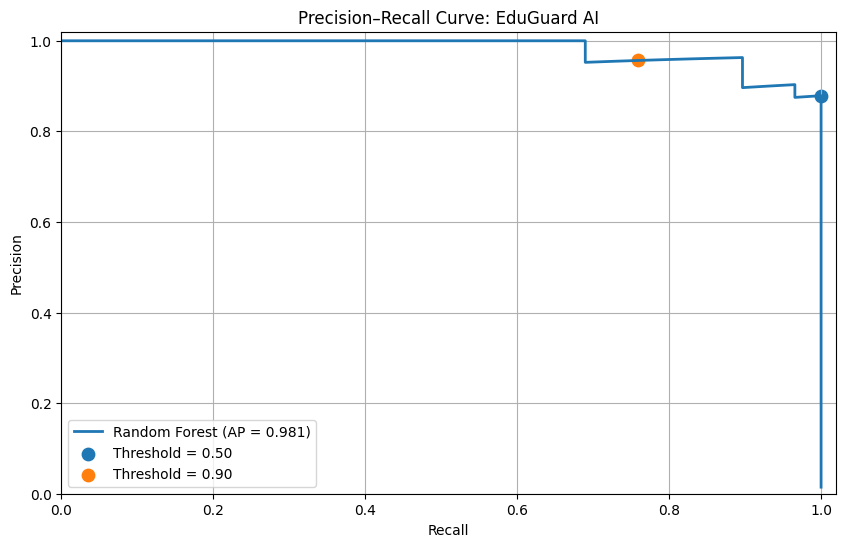

In [10]:
# ==========================================
# 5A. PRECISION-RECALL CURVE
# ==========================================
precision, recall, thresholds = precision_recall_curve(
    y_test,
    cheating_probabilities
)

plt.figure()
plt.plot(recall, precision, linewidth=2, label=f"Random Forest (AP = {ap_score:.3f})")

# Mark the two required operating points.
plt.scatter(
    default_recall,
    default_precision,
    s=80,
    label="Threshold = 0.50"
)
plt.scatter(
    strict_recall,
    strict_precision,
    s=80,
    label="Threshold = 0.90"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve: EduGuard AI")
plt.xlim(0, 1.02)
plt.ylim(0, 1.02)
plt.legend()
plt.show()

In [11]:
# ==========================================
# 5B. THRESHOLD COMPARISON TABLE
# ==========================================
comparison = pd.DataFrame({
    "Threshold": [0.50, 0.90],
    "Precision": [default_precision, strict_precision],
    "Recall": [default_recall, strict_recall],
    "False Positives": [cm_default[0, 1], cm_strict[0, 1]],
    "False Negatives": [cm_default[1, 0], cm_strict[1, 0]]
})

display(comparison)

print("\nDataset-level summary")
print("----------------------")
print(f"Total modeling rows: {len(merged_df):,}")
print(f"Innocent rows:       {(y == 0).sum():,}")
print(f"Cheating rows:       {(y == 1).sum():,}")
print(f"Class imbalance:     {(y == 0).sum() / max((y == 1).sum(), 1):.1f}:1")
print(f"Average Precision:   {ap_score:.3f}")

,Threshold,Precision,Recall,False Positives,False Negatives
0,0.5,0.878788,1.000000,4,0
1,0.9,0.956522,0.758621,1,7



Dataset-level summary
----------------------
Total modeling rows: 10,000
Innocent rows:       9,853
Cheating rows:       147
Class imbalance:     67.0:1
Average Precision:   0.981


# 🎯 Executive Recommendation

### To the University Board of Directors

The completed pipeline uses asynchronous timestamp alignment, missing-data recovery, rolling-window feature engineering, class-balanced Random Forest training, and probability-based decision thresholding.

For the final operating rule, the notebook uses a **0.90 probability threshold**. On the held-out test set, this threshold changes the precision/recall trade-off relative to the conventional 0.50 threshold. The exact measured values are shown in the evaluation table above.

### Why this protects innocent students

- A short-lived sensor fluctuation is less likely to dominate the decision because 10-second rolling features are included.
- Missing video telemetry is recovered instead of deleting the exam timeline.
- Class imbalance is explicitly handled with `class_weight="balanced"`.
- The system does not treat a 50% probability as sufficient evidence for a cheating flag.
- The final decision requires **at least 90% model probability**.

### Deployment note

The results in this notebook are based only on the supplied dataset and held-out test split. Before real university deployment, the threshold and model should be validated on additional exams and independently audited for false accusations across different recording conditions.

**Final configuration:** `RandomForestClassifier(class_weight="balanced")` + **0.90 probability threshold**.